# PS01 : Linear Algebra และ Optimization

**วิธีทำ:** แต่ละข้อให้ลองคำนวณด้วยมือก่อน
แล้วค่อยเขียนโค้ดตรวจว่าตรงกันไหม


| ข้อ | ต้องมี                                                  |
|---|---------------------------------------------------------|
| 1 | coding TODO 1–2                                         |
| 2 | coding TODO 1–3                                         |
| 3 | ตอบ (a)–(c) พร้อมเหตุผล (หา $f''$ ด้วยมือ)              |
| 4 | คำนวณด้วยมือ (a)–(c) + code TODO 1–3                    |
| 5 | คำนวณด้วยมือ 5.1 (a)(b) + code TODO 1–3+|

**หมายเหตุ**`# TODO` คือส่วนที่ต้องเติม

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

---
# ข้อ 1 : $Ax = b$ กำหนดได้ 2 แบบ

จากสมการที่กำหนดให้

$$\begin{align*}
3x_1 - x_2 &= 7\\
x_1 + 2x_2 &= 7
\end{align*}$$

**(a)** เขียนระบบนี้ในรูป $Ax = b$ แล้วระบุว่า $A$, $x$, $b$ คืออะไร

**(b) มองเป็น row แต่ละสมการคือ สมการเส้นตรง 1 เส้นในระนาบ
จงหาจุดตัดของสองเส้นด้วยมือ แล้วแทนค่ากลับไปตรวจว่าถูกต้อง (แก้ด้วย Geometry/แทนค่า)

**(c) มองเป็น column เขียน $Ax$ ให้อยู่ในรูป
**ผลรวมเชิงเส้นของคอลัมน์ของ $A$**

$$Ax = x_1\begin{bmatrix}3\\1\end{bmatrix} + x_2\begin{bmatrix}-1\\2\end{bmatrix}$$

และตรวจว่าค่า $x_1, x_2$ ที่ได้จากข้อ (b) ทำให้สมการนี้เป็นจริงหรือไม่

**(d)** เติมโค้ดในเซลล์ล่างเพื่อตรวจคำตอบ

In [2]:
# TODO 1: สร้าง A และ b แล้วแก้สมการด้วย np.linalg.solve(A, b)  ->  เก็บไว้ในตัวแปร x_sol
A = np.array([[3.0, -1.0],
              [1.0,  2.0]])
b = np.array([7.0, 7.0])
x_sol = np.linalg.solve(A, b)
print("x_sol =", x_sol)

# TODO 2: ตรวจแบบ column : คำนวณ x_sol[0] * (column 0 ของ A) + x_sol[1] * (column 1 ของ A)
b_check = x_sol[0] * A[:, 0] + x_sol[1] * A[:, 1]
print("x_sol[0]*col0 + x_sol[1]*col1 =", b_check)
print("เท่ากับ b หรือไม่ :", np.allclose(b_check, b))

#         แล้วเช็คว่าได้ b กลับมาจริงไหม (ใช้ np.allclose)
#         ข้อควรระวัง: ตั้งชื่อ x_sol ไม่ใช่ x เพื่อไม่ให้ซ้ำกับตัวแปร x ของข้อถัดไป
#         คำใบ้: คอลัมน์ที่ j ของ A เขียนได้ว่า A[:, j]

x_sol = [3. 2.]
x_sol[0]*col0 + x_sol[1]*col1 = [7. 7.]
เท่ากับ b หรือไม่ : True


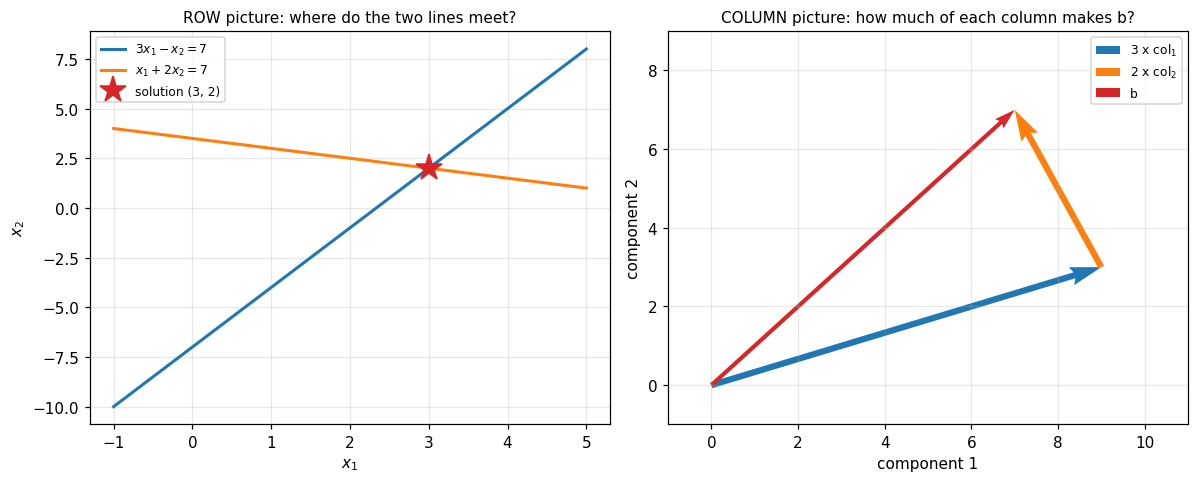

In [3]:
# ---------- โค้ดวาดรูป ----------
# !! cell นี้ใช้ A, b, x_sol จาก TODO ข้างบน ต้องทำ cell ก่อนหน้านี้ให้เสร็จก่อน
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ----- ซ้าย : row  -----
t = np.linspace(-1, 5, 100)
axes[0].plot(t, 3 * t - 7, lw=2, label="$3x_1 - x_2 = 7$")
axes[0].plot(t, (7 - t) / 2, lw=2, label="$x_1 + 2x_2 = 7$")
axes[0].plot(x_sol[0], x_sol[1], "*", ms=18, color="tab:red", label=f"solution ({x_sol[0]:.0f}, {x_sol[1]:.0f})")
axes[0].set_title("ROW picture: where do the two lines meet?", fontsize=10)
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$"); axes[0].legend(fontsize=8)

# ----- ขวา : column  -----
c0, c1 = A[:, 0], A[:, 1]
axes[1].quiver(0, 0, *(x_sol[0] * c0), angles="xy", scale_units="xy", scale=1,
               color="tab:blue", width=0.012, label=f"{x_sol[0]:.0f} x col$_1$")
axes[1].quiver(*(x_sol[0] * c0), *(x_sol[1] * c1), angles="xy", scale_units="xy", scale=1,
               color="tab:orange", width=0.012, label=f"{x_sol[1]:.0f} x col$_2$")
axes[1].quiver(0, 0, *b, angles="xy", scale_units="xy", scale=1,
               color="tab:red", width=0.008, label="b")
axes[1].set_xlim(-1, 11); axes[1].set_ylim(-1, 9)
axes[1].set_title("COLUMN picture: how much of each column makes b?", fontsize=10)
axes[1].set_xlabel("component 1"); axes[1].set_ylabel("component 2"); axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

---
# ข้อ 2 : Norm — วัด ขนาดของเวกเตอร์ได้หลายแบบ

$$\lVert x \rVert_1 = \sum_i \lvert x_i \rvert
\qquad
\lVert x \rVert_2 = \sqrt{\sum_i x_i^2}
$$

**(a)** สำหรับ $x = (3, -4, 12)^T$ จงคำนวณ $\lVert x\rVert_1$, $\lVert x\rVert_2$,
**ด้วยมือ**

**(b)** สำหรับ $u = (1,2,3)^T$ และ $v = (4,-2,3)^T$ จงหาระยะทาง
$d(u,v) = \lVert u - v \rVert$ ทั้งสองแบบ **ด้วยมือ**

**(c)** ให้ $p = (1,1,1,1)^T$ และ $q = (0,0,0,3)^T$

- วัดด้วย $\ell_1$ ตัวไหนอยู่ใกล้จุดกำเนิด (0,0,0,0) มากกว่า
- วัดด้วย $\ell_2$ ตัวไหนอยู่ใกล้จุดกำเนิด (0,0,0,0) มากกว่า

**(d)** ตรวจทุกข้อด้วย `np.linalg.norm`

In [4]:
x = np.array([3.0, -4.0, 12.0])
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, -2.0, 3.0])
p = np.array([1.0, 1.0, 1.0, 1.0])
q = np.array([0.0, 0.0, 0.0, 3.0])

# TODO 1: คำนวณ norm ทั้ง 2 แบบของ x
#         คำใบ้: np.linalg.norm(x, 1) / np.linalg.norm(x, 2)
x_norm1 = np.linalg.norm(x, 1)
x_norm2 = np.linalg.norm(x, 2)
print(f"||x||_1 = {x_norm1}")
print(f"||x||_2 = {x_norm2}")

# TODO 2: คำนวณระยะทาง d(u, v) ทั้ง 2 แบบ
d_uv_1 = np.linalg.norm(u - v, 1)
d_uv_2 = np.linalg.norm(u - v, 2)
print(f"d(u, v)_1 = {d_uv_1}")
print(f"d(u, v)_2 = {d_uv_2}")

# TODO 3: เทียบ p กับ q ว่าตัวไหนใกล้จุดกำเนิดกว่า ทั้งใน L1 และ L2
#         แล้ว print ให้เห็นชัดว่าคำตอบสองแบบขัดกัน
p_norm1, q_norm1 = np.linalg.norm(p, 1), np.linalg.norm(q, 1)
p_norm2, q_norm2 = np.linalg.norm(p, 2), np.linalg.norm(q, 2)
print(f"||p||_1 = {p_norm1}, ||q||_1 = {q_norm1}  ->  {'p' if p_norm1 < q_norm1 else 'q'} ใกล้จุดกำเนิดกว่า (L1)")
print(f"||p||_2 = {p_norm2}, ||q||_2 = {q_norm2}  ->  {'p' if p_norm2 < q_norm2 else 'q'} ใกล้จุดกำเนิดกว่า (L2)")
print("สังเกต: L1 กับ L2 ให้คำตอบขัดกัน! (ตัวชี้วัด 'ขนาด/ระยะทาง' ต่างกัน ผลเปรียบเทียบจึงต่างกันได้)")

||x||_1 = 19.0
||x||_2 = 13.0
d(u, v)_1 = 7.0
d(u, v)_2 = 5.0
||p||_1 = 4.0, ||q||_1 = 3.0  ->  q ใกล้จุดกำเนิดกว่า (L1)
||p||_2 = 2.0, ||q||_2 = 3.0  ->  p ใกล้จุดกำเนิดกว่า (L2)
สังเกต: L1 กับ L2 ให้คำตอบขัดกัน! (ตัวชี้วัด 'ขนาด/ระยะทาง' ต่างกัน ผลเปรียบเทียบจึงต่างกันได้)


---
# ข้อ 3 : Function ใด convex

**เกณฑ์ที่ใช้ในข้อนี้**

Function 1 ตัวแปรเป็น convex เมื่อ $f''(x) \geq 0$ **ทุกค่า** ของ $x$ ในโดเมน

**โจทย์:** ตัดสินว่าแต่ละ Function ต่อไปนี้ convex หรือไม่ โดยหา $f''$ ด้วยมือ แล้วดูกราฟใน cell ถัดไปประกอบ

| | Function | โดเมน |
|---|---|---|
| (a) | $f(x) = x^2 + 3x + 1$ | $\mathbb{R}$ |
| (b) | $f(x) = x^3$ | $\mathbb{R}$ |
| (c) | $f(x) = e^{x}$ | $\mathbb{R}$ |



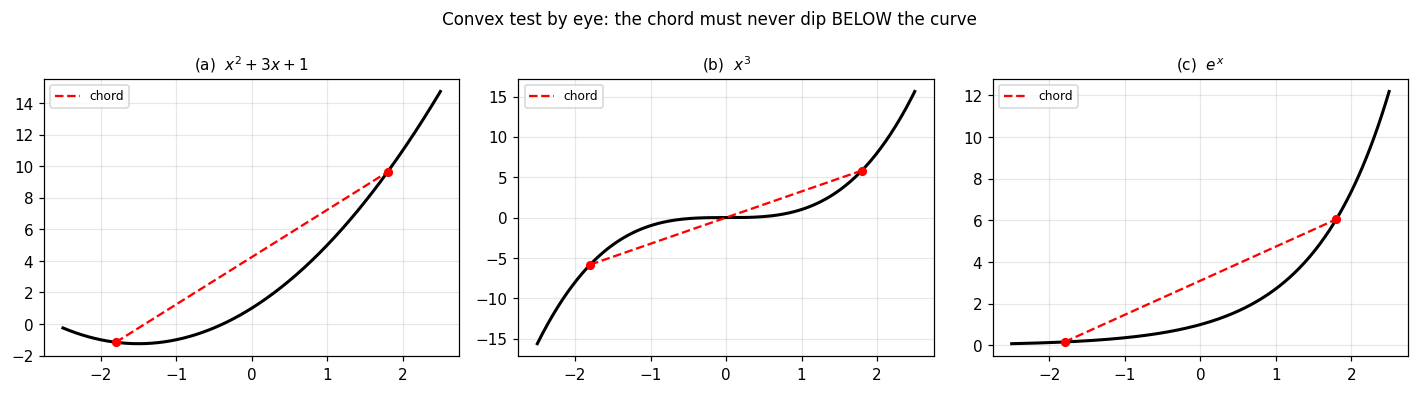

In [5]:
# ---------- โค้ดวาดรูปให้แล้ว : ดูรูปร่างของ Function 1 ตัวแปรทั้ง 3 ข้อ ----------
t = np.linspace(-2.5, 2.5, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, y, name in [(axes[0], t ** 2 + 3 * t + 1, "(a)  $x^2+3x+1$"),
                    (axes[1], t ** 3, "(b)  $x^3$"),
                    (axes[2], np.exp(t), "(c)  $e^x$")]:
    ax.plot(t, y, "k-", lw=2)
    # ลากเส้นตรงเชื่อม 2 จุดบนกราฟ : ถ้า convex เส้นตรงต้องอยู่เหนือกราฟเสมอ
    x1, x2 = -1.8, 1.8
    y1 = np.interp(x1, t, y)
    y2 = np.interp(x2, t, y)
    ax.plot([x1, x2], [y1, y2], "r--", lw=1.5, label="chord")
    ax.plot([x1, x2], [y1, y2], "ro", ms=5)
    ax.set_title(name, fontsize=10); ax.legend(fontsize=8)

fig.suptitle("Convex test by eye: the chord must never dip BELOW the curve", fontsize=11)
fig.tight_layout()
plt.show()

> **เขียนตอบข้อ 3 ตรงนี้** ตอบให้ครบทั้ง (a) - (c) หรือแยกใส่ word

**(a) $f(x) = x^2 + 3x + 1$**

$f'(x) = 2x + 3$, ดังนั้น $f''(x) = 2$

เนื่องจาก $f''(x) = 2 \geq 0$ **ทุกค่าของ $x \in \mathbb{R}$** จึงสรุปว่า **convex** (เป็นพาราโบลาหงายขึ้น คอร์ดจึงอยู่เหนือกราฟเสมอ ตรงกับรูปที่เห็น)

**(b) $f(x) = x^3$**

$f'(x) = 3x^2$, ดังนั้น $f''(x) = 6x$

$f''(x) = 6x \geq 0$ เมื่อ $x \geq 0$ แต่ $f''(x) < 0$ เมื่อ $x < 0$ นั่นคือเครื่องหมายของ $f''$ **เปลี่ยนที่ $x=0$** (จุด inflection) จึง **ไม่ convex บน $\mathbb{R}$** ทั้งหมด (จะเห็นในรูปว่าคอร์ดตัดผ่านใต้กราฟช่วง $x<0$)

**(c) $f(x) = e^x$**

$f'(x) = e^x$, ดังนั้น $f''(x) = e^x$

เนื่องจาก $e^x > 0$ **ทุกค่าของ $x \in \mathbb{R}$** จึงสรุปว่า **convex** (ตรงกับรูปที่คอร์ดอยู่เหนือกราฟเสมอ)

---
# ข้อ 4 : หาจุดต่ำสุดตรง ๆ ด้วย $\nabla f = 0$

$$f(x_1, x_2) = 3x_1^2 + 2x_2^2 + 2x_1x_2 - 8x_1 - 6x_2 + 5$$

ที่จุดต่ำสุดของฟังก์ชันเรียบ ๆ ความชันต้องเป็นศูนย์ทุกทิศ นั่นคือ $\nabla f = 0$
ข้อนี้จะใช้เงื่อนไขนั้นหาคำตอบตรง ๆ โดยไม่ต้องเดินทีละก้าว

**(a)** หา $\nabla f$ ด้วยมือ (อนุพันธ์ย่อยเทียบ $x_1$ และเทียบ $x_2$)

**(b)** กำหนด $\nabla f = 0$ จะได้สมการ 2 สมการ 2 ตัวแปร
จงจัดให้อยู่ในรูป $Ax = b$ **แบบเดียวกับข้อ 1** แล้วระบุ $A$ และ $b$

**(c)** แก้ระบบสมการด้วยมือ แล้วสำหรับหาค่า $x^\star$ และ $f(x^\star)$

**(d)** พิสูจน์ว่าจุดที่ได้เป็น **จุดต่ำสุดจริง** ไม่ใช่จุดสูงสุด
ด้วย 2 วิธี

- **ดูจากรูป** : contour ใน cell ถัดไปเป็นวงปิดล้อมรอบ $x^\star$ หรือไม่
- **ตรวจด้วยตัวเลข** : สุ่มจุดรอบ ๆ $x^\star$ หลาย ๆ จุด แล้วเช็คว่า
  $f$ ที่จุดเหล่านั้น **สูงกว่า** $f(x^\star)$ ทุกจุดหรือไม่

**(e)** ตรวจคำตอบด้วย `np.linalg.solve`

In [6]:
def f2(X):
    """f(x1, x2) — รับ array ขนาด (2,) หรือกริดก็ได้"""
    x1, x2 = X[0], X[1]
    return 3 * x1 ** 2 + 2 * x2 ** 2 + 2 * x1 * x2 - 8 * x1 - 6 * x2 + 5


# TODO 1: เขียน A และ b ที่หามาได้จากข้อ (b)
#         (ใส่เลข 4 ต่อท้ายชื่อ กันชนกับ A, b ของข้อ 1)
# grad f = (6x1 + 2x2 - 8, 4x2 + 2x1 - 6) = 0  ->  6x1 + 2x2 = 8 , 2x1 + 4x2 = 6
A4 = np.array([[6.0, 2.0],
               [2.0, 4.0]])
b4 = np.array([8.0, 6.0])

# TODO 2: แก้ A4 x = b4 ด้วย np.linalg.solve  ->  เก็บไว้ในตัวแปร x_star
#         แล้ว print x_star และ f2(x_star)
x_star = np.linalg.solve(A4, b4)
print("x_star =", x_star)
print("f2(x_star) =", f2(x_star))

# TODO 3: ยืนยันว่าเป็นจุดต่ำสุดจริง โดยสุ่มจุดรอบ ๆ x_star แล้วเช็คว่า f สูงกว่าทุกจุด
#         คำใบ้: rng = np.random.default_rng(0)
#                d = rng.normal(size=(2000, 2))            # สุ่มทิศทาง
#                d = 0.1 * d / np.linalg.norm(d, axis=1, keepdims=True)   # ยาว 0.1 เท่ากันหมด
#                แล้วเทียบ f2(x_star + dd) กับ f2(x_star) ให้ครบทุก dd
rng = np.random.default_rng(0)
d = rng.normal(size=(2000, 2))
d = 0.1 * d / np.linalg.norm(d, axis=1, keepdims=True)

f_star = f2(x_star)
f_neighbors = np.array([f2(x_star + dd) for dd in d])
print("จำนวนจุดที่ f(x_star + d) > f(x_star) :", np.sum(f_neighbors > f_star), "/", len(d))
print("ทุกจุดรอบ x_star มี f สูงกว่า f(x_star) หรือไม่ :", np.all(f_neighbors > f_star))

x_star = [1. 1.]
f2(x_star) = -2.0
จำนวนจุดที่ f(x_star + d) > f(x_star) : 2000 / 2000
ทุกจุดรอบ x_star มี f สูงกว่า f(x_star) หรือไม่ : True


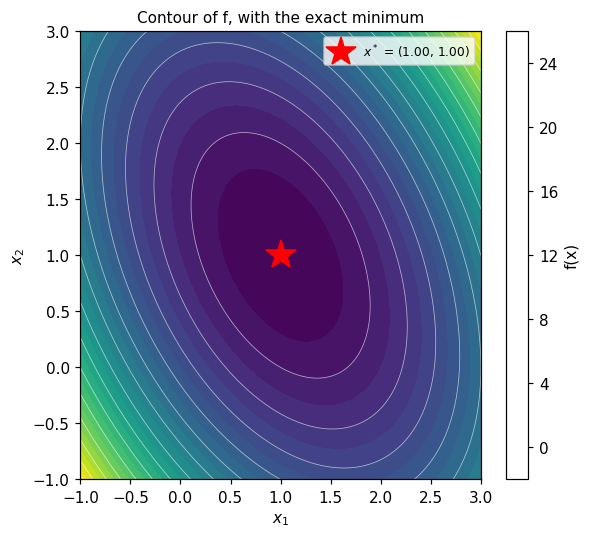

In [7]:
# ---------- โค้ดวาดรูป : contour ของ f พร้อมจุดต่ำสุด ----------
# !! เซลล์นี้ใช้ x_star จาก TODO 2 ข้างบน ต้องทำ cell นั้นให้เสร็จก่อน !!
g1, g2 = np.meshgrid(np.linspace(-1, 3, 300), np.linspace(-1, 3, 300))
Z = f2(np.stack([g1, g2]))

plt.figure(figsize=(5.5, 5))
plt.contourf(g1, g2, Z, levels=30, cmap="viridis")
plt.contour(g1, g2, Z, levels=15, colors="w", linewidths=0.5, alpha=0.6)
plt.plot(x_star[0], x_star[1], "*", ms=20, color="red",
         label=f"$x^*$ = ({x_star[0]:.2f}, {x_star[1]:.2f})")
plt.colorbar(label="f(x)")
plt.title("Contour of f, with the exact minimum", fontsize=10)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(fontsize=8); plt.grid(False)
plt.tight_layout()
plt.show()

---
# ข้อ 5 : Gradient Descent เดินไปหาคำตอบเดียวกันไหม

สูตรของ gradient descent คือ

$$x_{k+1} = x_k - \alpha \nabla f(x_k)$$

### 5.1 Function 1 ตัวแปร

ให้ $f(x) = x^2 - 4x + 5$ และ $\alpha = 0.1$

**(a)** หา $f'(x)$ ด้วยมือ แล้วทำ gradient descent **1 ก้าว** จาก $x_0 = 2$
ได้ $x_1$ เท่าไร

**(b)** ผลที่ได้จากข้อ (a) จงอธิบายว่าเกิดอะไรขึ้น
และบอกว่าจุด $x_0 = 2$ มีความพิเศษอย่างไร

**(c)** ทำ 3 ก้าวด้วยมือจาก $x_0 = 5$ แล้วเขียนโค้ดรันต่อจนลู่เข้า เพื่อทดสอบผลที่ได้ตรงตามหรือไม่

### 5.2 กลับไปที่ข้อ 4 (Function 2 ตัวแปร) ลองทำ

**(d)** เขียน gradient descent สำหรับ $f$ ในข้อ 4 โดยใช้ $\nabla f(x) = Ax - b$
(ใช้ $A$, $b$ ชุดเดียวกับข้อ 4)
เริ่มจาก $x_0 = (0,0)^T$ ด้วย $\alpha = 0.1$ แล้วตรวจว่าลู่เข้าหา $x^\star$ ของข้อ 4 หรือไม่

**(e)** ปัญหานี้มีค่า $\alpha$ ที่ใหญ่ที่สุดที่ยังไม่ทำให้ลู่ออกอยู่ค่าหนึ่ง
จง **หาค่านั้นด้วยการทดลอง** โดยไล่ $\alpha$ ขึ้นทีละนิด (เช่น 0.05, 0.1, 0.15, ...)
แล้วดูว่าเริ่มมีการกระโดที่ผิดปกติ หรือลู่ออกผิดปกติ

x0 = 2.0, x1 = 2.0
3 ก้าวแรกจาก x0 = 5 : [5.0, 4.4, 3.9200000000000004, 3.5360000000000005]
ค่าสุดท้ายหลัง 40 ก้าว : 2.0003987683987354


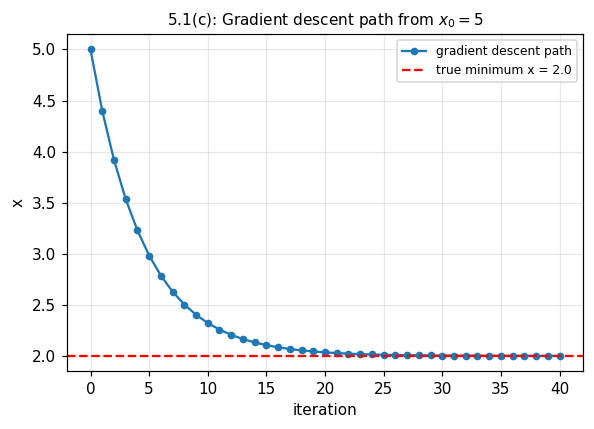

In [8]:
# ---------- 5.1 กรณี 1 ตัวแปร ----------
def f1(x):
    return x ** 2 - 4 * x + 5


def grad_f1(x):
    # TODO 1: เขียนอนุพันธ์ f'(x) ที่หามาได้จากข้อ (a)
    return 2 * x - 4


# TODO 2: ทำ gradient descent จาก x0 = 2 จำนวน 1 ก้าว ด้วย alpha = 0.1
#         แล้ว print ค่า x1 ที่ได้ เทียบกับ x0
alpha = 0.1
x0 = 2.0
x1 = x0 - alpha * grad_f1(x0)
print(f"x0 = {x0}, x1 = {x1}")

# TODO 3: ทำ gradient descent จาก x0 = 5 จำนวน 40 ก้าว (alpha = 0.1)
#         เก็บ path ไว้ แล้ววาดกราฟ x เทียบกับจำนวนรอบ
#         พร้อมลากเส้นแนวนอนที่คำตอบจริง (หาได้จากการจัดรูป f ในข้อ (b))
x_true = 2.0  # f(x) = (x-2)^2 + 1  ->  minimum ที่ x = 2

xk = 5.0
path = [xk]
for _ in range(40):
    xk = xk - alpha * grad_f1(xk)
    path.append(xk)

print("3 ก้าวแรกจาก x0 = 5 :", path[:4])
print("ค่าสุดท้ายหลัง 40 ก้าว :", path[-1])

plt.figure(figsize=(5.5, 4))
plt.plot(path, "o-", ms=4, label="gradient descent path")
plt.axhline(x_true, color="red", ls="--", label=f"true minimum x = {x_true}")
plt.xlabel("iteration"); plt.ylabel("x")
plt.title("5.1(c): Gradient descent path from $x_0=5$", fontsize=10)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# ---------- 5.2 กรณี 2 ตัวแปร : ใช้ A4, b4 จากข้อ 4 ----------
# TODO 4: เขียน Function gradient descent สำหรับ f ในข้อ 4
#         โดยใช้ grad = A4 @ x - b4  แล้วรัน 100 รอบจาก x0 = (0, 0) ด้วย alpha = 0.1
#         print ค่าสุดท้าย เทียบกับ x_star ของข้อ 4 (ควรตรงกัน)
def gradient_descent_f2(x0, alpha, n_steps):
    xk = np.array(x0, dtype=float)
    path = [xk.copy()]
    for _ in range(n_steps):
        grad = A4 @ xk - b4
        xk = xk - alpha * grad
        path.append(xk.copy())
    return xk, np.array(path)

x_final, path4 = gradient_descent_f2(x0=(0.0, 0.0), alpha=0.1, n_steps=100)
print("x_final (gradient descent) =", x_final)
print("x_star  (np.linalg.solve)  =", x_star)
print("ตรงกันหรือไม่ :", np.allclose(x_final, x_star, atol=1e-4))

# TODO 5: ไล่ค่า alpha ขึ้นทีละนิด (เช่น 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35)
#         แล้ว print ค่าสุดท้ายของแต่ละ alpha ดูว่าเริ่มระเบิดที่ประมาณเท่าไร
for alpha_try in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]:
    x_final_try, _ = gradient_descent_f2(x0=(0.0, 0.0), alpha=alpha_try, n_steps=100)
    print(f"alpha = {alpha_try:.2f}  ->  x_final = {x_final_try}")

# eigenvalue ของ A4 บอกขอบเขตทางทฤษฎีของ alpha ที่ยังลู่เข้า: alpha < 2/lambda_max
eigvals = np.linalg.eigvalsh(A4)
print("\neigenvalues ของ A4 :", eigvals)
print("ขอบเขตทางทฤษฎี alpha < 2/lambda_max =", 2 / eigvals.max())

x_final (gradient descent) = [1. 1.]
x_star  (np.linalg.solve)  = [1. 1.]
ตรงกันหรือไม่ : True
alpha = 0.05  ->  x_final = [1. 1.]
alpha = 0.10  ->  x_final = [1. 1.]
alpha = 0.15  ->  x_final = [1. 1.]
alpha = 0.20  ->  x_final = [1. 1.]
alpha = 0.25  ->  x_final = [1. 1.]
alpha = 0.30  ->  x_final = [-8270238.975  -5111288.3997]
alpha = 0.35  ->  x_final = [-4.0930e+18 -2.5296e+18]

eigenvalues ของ A4 : [2.7639 7.2361]
ขอบเขตทางทฤษฎี alpha < 2/lambda_max = 0.276393202250021


---
## สรุปสิ่งที่ต้องส่ง

| ข้อ | ต้องมี                                                  |
|---|---------------------------------------------------------|
| 1 | coding TODO 1–2                                         |
| 2 | coding TODO 1–3                                         |
| 3 | ตอบ (a)–(c) พร้อมเหตุผล (หา $f''$ ด้วยมือ)              |
| 4 | คำนวณด้วยมือ (a)–(c) + code TODO 1–3                    |
| 5 | คำนวณด้วยมือ 5.1 (a)(b) + code TODO 1–3+|